In [1]:
import pandas as pd
import numpy as np

np.random.seed(5)

x = np.linspace(-10, 10, 100)

y = x**2 + np.random.normal(0, 5, 100)

# Convert into two classes
label = (y > 30).astype(int)

data = pd.DataFrame({
    'X': x,
    'Y': y,
    'Label': label
})

data.to_csv("quadratic_svm.csv", index=False)

print("Dataset created successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset created successfully!
Shape: (100, 3)
           X           Y  Label
0 -10.000000  102.206137      1
1  -9.797980   94.346057      1
2  -9.595960  104.236297      1
3  -9.393939   86.985637      1
4  -9.191919   85.039428      1


In [3]:
data = pd.read_csv("quadratic_svm.csv")

print(data)

            X           Y  Label
0  -10.000000  102.206137      1
1   -9.797980   94.346057      1
2   -9.595960  104.236297      1
3   -9.393939   86.985637      1
4   -9.191919   85.039428      1
..        ...         ...    ...
95   9.191919   88.432568      1
96   9.393939   86.018947      1
97   9.595960   89.671840      1
98   9.797980   98.468196      1
99  10.000000  102.502437      1

[100 rows x 3 columns]


In [5]:
X = data[['X', 'Y']]
y = data['Label']

print("X:")
print(X.head())

print("\nY:")
print(y.head())

X:
           X           Y
0 -10.000000  102.206137
1  -9.797980   94.346057
2  -9.595960  104.236297
3  -9.393939   86.985637
4  -9.191919   85.039428

Y:
0    1
1    1
2    1
3    1
4    1
Name: Label, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print("X_train:", x_train.shape)
print("Y_train:", y_train.shape)
print("X_test:", x_test.shape)
print("Y_test:", y_test.shape)

X_train: (80, 2)
Y_train: (80,)
X_test: (20, 2)
Y_test: (20,)


In [9]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Data standardized successfully!")

Data standardized successfully!


In [11]:
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    random_state=0
)

model.fit(x_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [13]:
svc_prediction = model.predict(x_test)

print("SVM Prediction:")
print(svc_prediction)

SVM Prediction:
[0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0]


In [15]:
from sklearn import metrics

conf_mat = metrics.confusion_matrix(
    y_test,
    svc_prediction
)

print("Confusion Matrix :")
print(conf_mat)

Confusion Matrix :
[[15  0]
 [ 1  4]]


In [17]:
accuracy_score = metrics.accuracy_score(
    y_test,
    svc_prediction
)

print("Accuracy Score :", accuracy_score)
print("Accuracy in Percentage :", int(accuracy_score * 100), "%")

Accuracy Score : 0.95
Accuracy in Percentage : 95 %


In [19]:
print("Classification Report:")
print(
    metrics.classification_report(
        y_test,
        svc_prediction
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.80      0.89         5

    accuracy                           0.95        20
   macro avg       0.97      0.90      0.93        20
weighted avg       0.95      0.95      0.95        20



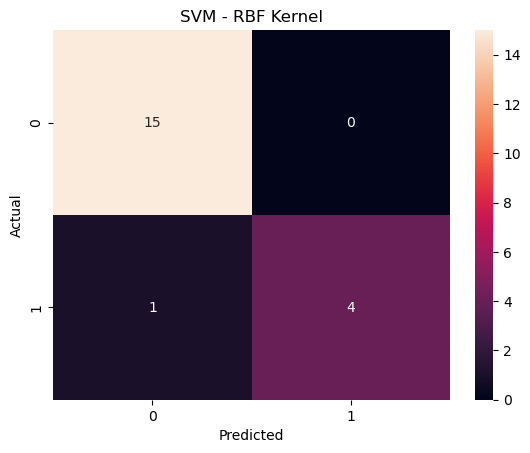

In [21]:
import seaborn as sn
import matplotlib.pyplot as plt

conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)

plt.title("SVM - RBF Kernel")
plt.show()

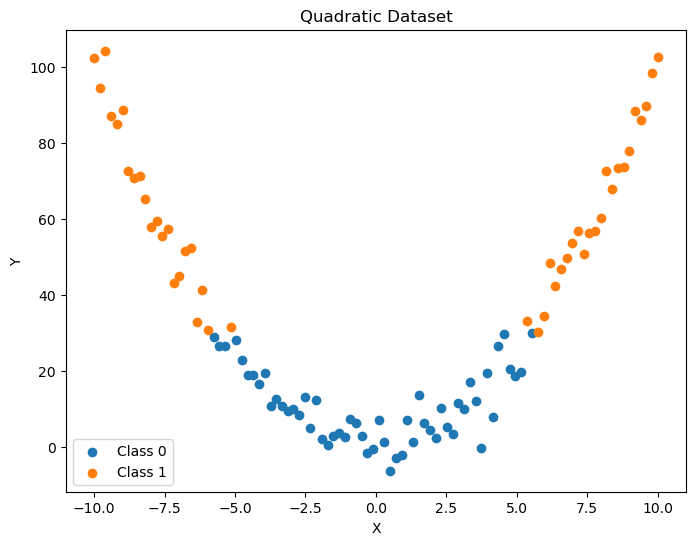

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data[data['Label'] == 0]['X'],
    data[data['Label'] == 0]['Y'],
    label='Class 0'
)

plt.scatter(
    data[data['Label'] == 1]['X'],
    data[data['Label'] == 1]['Y'],
    label='Class 1'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Quadratic Dataset")
plt.legend()
plt.show()